In [ ]:
!pip install segmentation-models-pytorch

In [ ]:
import segmentation_models_pytorch as smp

Nombre de fichiers JSON : 5598


100%|██████████| 5598/5598 [01:20<00:00, 69.45it/s]



Distribution des classes :

          Classe  Nombre
0  un-classified  165780
1      no-damage  117426
2      destroyed   13227
3   major-damage   14161
4   minor-damage   14980


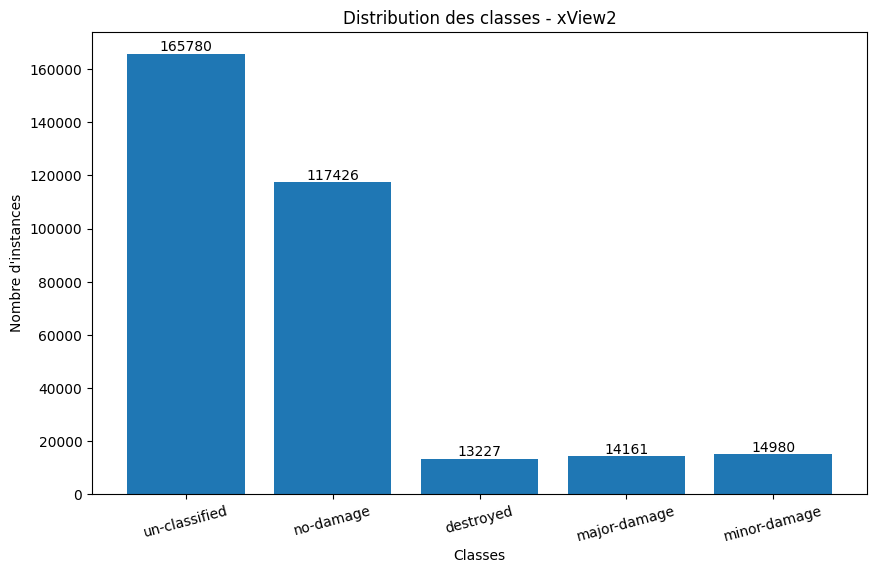

In [1]:
# ============================================================
# ANALYSE DES CLASSES xView2
# ============================================================

import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

# ── PATH LABELS ─────────────────────────────────────────────
BASE = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test"
TRAIN_LBL = os.path.join(BASE, "train/train/labels")

# ── CLASSES ────────────────────────────────────────────────
classes = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed",
    "un-classified"
]

# ── COMPTEUR ───────────────────────────────────────────────
counter = Counter()

# ── LECTURE DES JSON ───────────────────────────────────────
json_files = [f for f in os.listdir(TRAIN_LBL) if f.endswith(".json")]

print("Nombre de fichiers JSON :", len(json_files))

for jf in tqdm(json_files):

    path = os.path.join(TRAIN_LBL, jf)

    with open(path) as f:
        data = json.load(f)

    features = data["features"].get("xy", [])

    for feat in features:

        subtype = feat["properties"].get(
            "subtype",
            "un-classified"
        )

        counter[subtype] += 1

# ── DATAFRAME ──────────────────────────────────────────────
df = pd.DataFrame({
    "Classe": list(counter.keys()),
    "Nombre": list(counter.values())
})

# ── AFFICHAGE TABLEAU ──────────────────────────────────────
print("\nDistribution des classes :\n")
print(df)

# ── HISTOGRAMME ────────────────────────────────────────────
plt.figure(figsize=(10,6))

bars = plt.bar(
    df["Classe"],
    df["Nombre"]
)

# Affichage des valeurs sur les barres
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        int(yval),
        ha='center',
        va='bottom'
    )

plt.title("Distribution des classes - xView2")
plt.xlabel("Classes")
plt.ylabel("Nombre d'instances")

plt.xticks(rotation=15)

plt.show()

In [1]:
# ============================================================
# PRETRAITEMENT AVANCE xView2
# Gestion du déséquilibre + augmentation + PRE/POST
# ============================================================

# ── IMPORTS ─────────────────────────────────────────────────
import os
import json
import random
import numpy as np
import cv2
import torch

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

import albumentations as A
from albumentations.pytorch import ToTensorV2

# ── PATHS ──────────────────────────────────────────────────
BASE = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test"

TRAIN_IMG = os.path.join(BASE, "train/train/images")
TRAIN_LBL = os.path.join(BASE, "train/train/labels")

print("Images :", len(os.listdir(TRAIN_IMG)))
print("Labels :", len(os.listdir(TRAIN_LBL)))

# ============================================================
# 1. CLASSES
# ============================================================

# On ignore volontairement "un-classified"

DAMAGE_CLASSES = {
    'no-damage': 1,
    'minor-damage': 2,
    'major-damage': 3,
    'destroyed': 4
}

# ============================================================
# 2. JSON → MASK
# ============================================================

from shapely.wkt import loads as wkt_loads

def json_to_mask(json_path, size=1024):

    mask = np.zeros((size, size), dtype=np.uint8)

    with open(json_path) as f:
        data = json.load(f)

    for feat in data['features'].get('xy', []):

        subtype = feat['properties'].get('subtype')

        # ignorer les classes inconnues
        if subtype not in DAMAGE_CLASSES:
            continue

        cls = DAMAGE_CLASSES[subtype]

        wkt = feat.get('wkt', '')

        try:
            poly = wkt_loads(wkt)

            coords = np.array(
                poly.exterior.coords,
                dtype=np.int32
            )

            cv2.fillPoly(mask, [coords], cls)

        except:
            pass

    # éliminer les masques presque vides
    if np.sum(mask > 0) < 500:
        return None

    return mask

# ============================================================
# 3. CREATION DES PAIRES
# ============================================================

all_files = os.listdir(TRAIN_IMG)

post_files = [
    f for f in all_files
    if "_post_disaster" in f
]

pairs = []

for pf in post_files:

    base = pf.replace("_post_disaster.png", "")

    pre = os.path.join(
        TRAIN_IMG,
        base + "_pre_disaster.png"
    )

    post = os.path.join(
        TRAIN_IMG,
        base + "_post_disaster.png"
    )

    lbl = os.path.join(
        TRAIN_LBL,
        base + "_post_disaster.json"
    )

    if (
        os.path.exists(pre)
        and os.path.exists(post)
        and os.path.exists(lbl)
    ):

        pairs.append({
            "pre": pre,
            "post": post,
            "label": lbl
        })

print("Pairs originales :", len(pairs))

# ============================================================
# 4. OVERSAMPLING DES CLASSES RARES
# ============================================================
balanced_pairs = []

for p in pairs:

    with open(p["label"]) as f:
        data = json.load(f)

    text = str(data)

    # 🔴 no-damage → sous-échantillonnage
    if "no-damage" in text:
        if np.random.rand() < 0.3:
            balanced_pairs.append(p)

    # 🔥 classes rares → oversampling
    elif "destroyed" in text:
        balanced_pairs.extend([p] * 6)

    elif "major-damage" in text:
        balanced_pairs.extend([p] * 4)

    elif "minor-damage" in text:
        balanced_pairs.extend([p] * 2)

    else:
        balanced_pairs.append(p)

print("Pairs après balancing :", len(balanced_pairs))



# ============================================================
# 5. TRAIN / VALIDATION SPLIT
# ============================================================

train_pairs, val_pairs = train_test_split(
    pairs,
    test_size=0.2,
    random_state=42
)

print("Train :", len(train_pairs))
print("Validation :", len(val_pairs))

# ============================================================
# 6. DATA AUGMENTATION AVANCEE
# ============================================================

transform = A.Compose([

    A.Resize(256, 256),

    # flips
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),

    # rotations
    A.RandomRotate90(p=0.5),

    # transformations géométriques
    A.ShiftScaleRotate(
        shift_limit=0.08,
        scale_limit=0.15,
        rotate_limit=30,
        border_mode=cv2.BORDER_REFLECT,
        p=0.5
    ),

    # luminosité / contraste
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    ),

    # bruit
    A.GaussNoise(
        std_range=(0.02, 0.08),
        p=0.3
    ),

    # blur
    A.GaussianBlur(
        blur_limit=(3, 5),
        p=0.2
    ),

    # amélioration contraste satellite
    A.CLAHE(
        clip_limit=2.0,
        p=0.3
    ),

    A.Normalize(),

    ToTensorV2()

])

# ============================================================
# 7. DATASET PYTORCH
# ============================================================

class XViewDataset(Dataset):

    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        p = self.pairs[idx]

        # ── IMAGE PRE ─────────────────────────────
        pre = cv2.imread(p["pre"])

        pre = cv2.cvtColor(
            pre,
            cv2.COLOR_BGR2RGB
        )

        # ── IMAGE POST ────────────────────────────
        post = cv2.imread(p["post"])

        post = cv2.cvtColor(
            post,
            cv2.COLOR_BGR2RGB
        )

        # ── CONCAT PRE + POST → 6 CANAUX ─────────
        img = np.concatenate(
            [pre, post],
            axis=2
        )

        # ── MASK ──────────────────────────────────
        mask = json_to_mask(p["label"])

        # si image vide → prendre une autre image
        if mask is None:

            return self.__getitem__(
                random.randint(
                    0,
                    len(self.pairs)-1
                )
            )

        # ── AUGMENTATION IMAGE + MASK ────────────
        aug = transform(
            image=img,
            mask=mask
        )

        img = aug["image"]

        mask = aug["mask"]

        mask = torch.tensor(mask).long()

        return img, mask

# ============================================================
# 8. DATALOADERS
# ============================================================

train_dataset = XViewDataset(train_pairs)
val_dataset   = XViewDataset(val_pairs)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2
)

print("Pretraitement prêt.")
print("Train batches :", len(train_loader))
print("Validation batches :", len(val_loader))

# ============================================================
# 9. CALCUL AUTOMATIQUE DES POIDS
# ============================================================

counts = np.array([
    117426,  # no-damage
    14980,   # minor
    14161,   # major
    13227    # destroyed
])

freq = counts / counts.sum()

weights = 1 / np.sqrt(freq)

weights = weights / weights.sum()

weights = torch.tensor(
    [0.01] + list(weights),
    dtype=torch.float32
)

print("\nPoids des classes :")
print(weights)

Images : 5598
Labels : 5598
Pairs originales : 2799
Pairs après balancing : 3652
Train : 2239
Validation : 560
Pretraitement prêt.
Train batches : 560
Validation batches : 140

Poids des classes :
tensor([0.0100, 0.1035, 0.2899, 0.2981, 0.3085])


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
# ============================================================
# VISUALISATION DES CLASSES APRES PRETRAITEMENT
# ============================================================

import json
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

counter = Counter()

# on parcourt les labels des pairs APRES équilibrage
for p in tqdm(train_pairs):

    with open(p["label"]) as f:
        data = json.load(f)

    for feat in data["features"].get("xy", []):

        subtype = feat["properties"].get("subtype")

        if subtype is None:
            continue

        counter[subtype] += 1


# conversion en tableau
classes = list(counter.keys())
values = list(counter.values())

print("\nDistribution APRES pretraitement :")
for c, v in zip(classes, values):
    print(c, ":", v)

# ============================================================
# HISTOGRAMME
# ============================================================

plt.figure(figsize=(10,6))

bars = plt.bar(classes, values)

# valeurs sur les barres
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        int(y),
        ha='center',
        va='bottom'
    )

plt.title("Distribution des classes après prétraitement")
plt.xlabel("Classes")
plt.ylabel("Nombre d'instances")
plt.xticks(rotation=20)
plt.show()# ============================================================
# VISUALISATION DES CLASSES APRES PRETRAITEMENT
# ============================================================

import json
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

counter = Counter()

# on parcourt les labels des pairs APRES équilibrage
for p in tqdm(train_pairs):

    with open(p["label"]) as f:
        data = json.load(f)

    for feat in data["features"].get("xy", []):

        subtype = feat["properties"].get("subtype")

        if subtype is None:
            continue

        counter[subtype] += 1


# conversion en tableau
classes = list(counter.keys())
values = list(counter.values())

print("\nDistribution APRES pretraitement :")
for c, v in zip(classes, values):
    print(c, ":", v)

# ============================================================
# HISTOGRAMME
# ============================================================

plt.figure(figsize=(10,6))

bars = plt.bar(classes, values)

# valeurs sur les barres
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        int(y),
        ha='center',
        va='bottom'
    )

plt.title("Distribution des classes après prétraitement")
plt.xlabel("Classes")
plt.ylabel("Nombre d'instances")
plt.xticks(rotation=20)
plt.show()

Device: cuda
Pairs: 2799

Epoch 1
Train Loss: 0.32937143331925783
Val Loss: 0.19194855115243367
Val IoU: 0.36746525534025626

Epoch 2
Train Loss: 0.17256031121526447
Val Loss: 0.13996334445795844
Val IoU: 0.4208914283558811

Epoch 3
Train Loss: 0.14595808779953845
Val Loss: 0.12271679842046329
Val IoU: 0.53480589730399

Epoch 4
Train Loss: 0.13457498996119413
Val Loss: 0.11386259548099978
Val IoU: 0.53480589730399

Epoch 5
Train Loss: 0.12907154774293303
Val Loss: 0.10646356602332421
Val IoU: 0.53480589730399


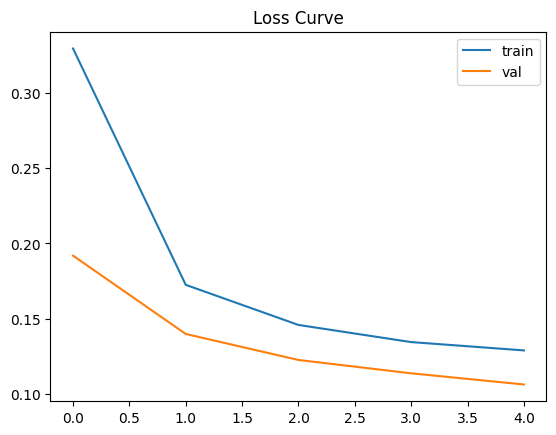

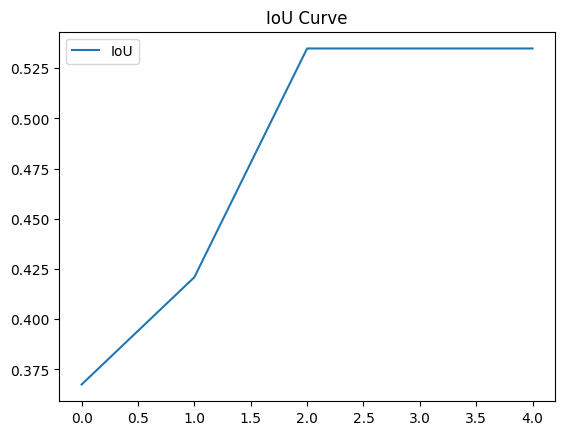

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8096584..2.2489083].


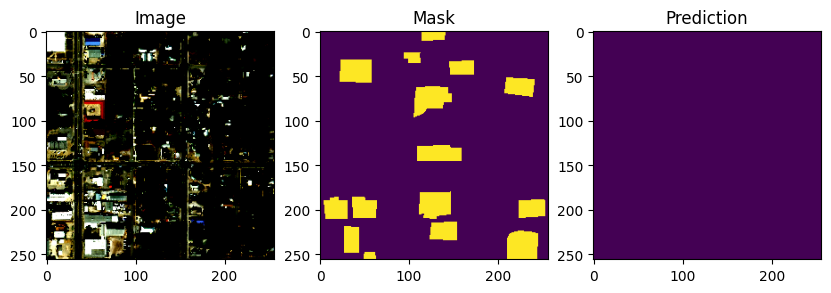

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6384108..2.2489083].


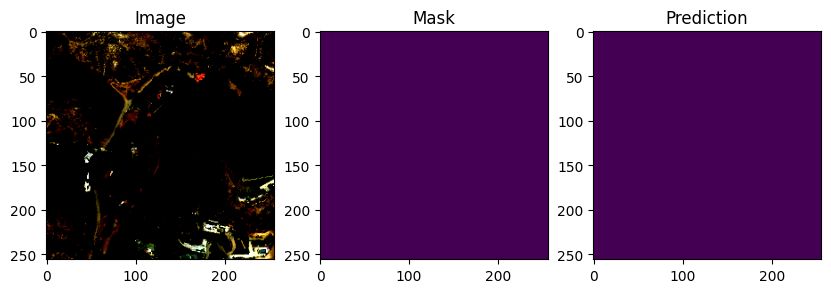

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9980307..2.2489083].


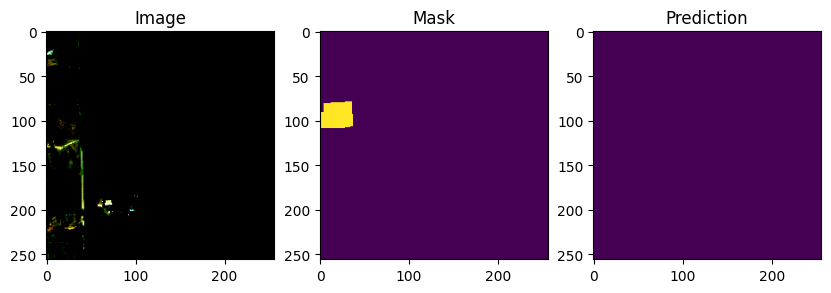

In [2]:
# ============================================================
# xView2 - FINAL TRAINING PIPELINE (CLEAN + STABLE)
# ============================================================

import os, json, cv2, numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split

# ============================================================
# DEVICE
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# PATHS
# ============================================================
BASE = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test"
TRAIN_IMG = os.path.join(BASE, "train/train/images")
TRAIN_LBL = os.path.join(BASE, "train/train/labels")

NUM_CLASSES = 5
IMG_SIZE = 256

# ============================================================
# MASK
# ============================================================
from shapely.wkt import loads as wkt_loads

def json_to_mask(json_path):
    mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    with open(json_path) as f:
        data = json.load(f)

    for feat in data['features'].get('xy', []):
        try:
            poly = wkt_loads(feat['wkt'])
            coords = np.array(poly.exterior.coords, dtype=np.int32)
            cv2.fillPoly(mask, [coords], 1)
        except:
            pass

    return mask

# ============================================================
# PAIRS
# ============================================================
all_files = os.listdir(TRAIN_IMG)
post_files = [f for f in all_files if "_post_disaster" in f]

pairs = []
for pf in post_files:
    base = pf.replace("_post_disaster.png", "")

    pre = os.path.join(TRAIN_IMG, base + "_pre_disaster.png")
    post = os.path.join(TRAIN_IMG, base + "_post_disaster.png")
    lbl = os.path.join(TRAIN_LBL, base + "_post_disaster.json")

    if os.path.exists(pre) and os.path.exists(post) and os.path.exists(lbl):
        pairs.append({"pre": pre, "post": post, "label": lbl})

print("Pairs:", len(pairs))

# ============================================================
# SPLIT
# ============================================================
train_pairs, val_pairs = train_test_split(pairs, test_size=0.2, random_state=42)

# ============================================================
# TRANSFORM
# ============================================================
transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(),
    ToTensorV2()
])

# ============================================================
# DATASET (FIXED INDENTATION + SAFE)
# ============================================================
class XDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        p = self.pairs[idx]

        pre = cv2.imread(p["pre"])
        post = cv2.imread(p["post"])

        pre = cv2.cvtColor(pre, cv2.COLOR_BGR2RGB)
        post = cv2.cvtColor(post, cv2.COLOR_BGR2RGB)

        img = np.concatenate([pre, post], axis=2)

        mask = json_to_mask(p["label"])

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

        aug = transform(image=img, mask=mask)

        img = aug["image"]
        mask = aug["mask"]

        mask = torch.as_tensor(mask, dtype=torch.long)

        return img, mask

train_loader = DataLoader(XDataset(train_pairs), batch_size=4, shuffle=True, num_workers=2)
val_loader   = DataLoader(XDataset(val_pairs), batch_size=4, shuffle=False, num_workers=2)

# ============================================================
# U-NET
# ============================================================
class DoubleConv(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c,out_c,3,padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c,out_c,3,padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self,x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.d1=DoubleConv(6,64)
        self.d2=DoubleConv(64,128)
        self.d3=DoubleConv(128,256)

        self.p=nn.MaxPool2d(2)

        self.b=DoubleConv(256,512)

        self.u3=nn.ConvTranspose2d(512,256,2,2)
        self.c3=DoubleConv(512,256)

        self.u2=nn.ConvTranspose2d(256,128,2,2)
        self.c2=DoubleConv(256,128)

        self.u1=nn.ConvTranspose2d(128,64,2,2)
        self.c1=DoubleConv(128,64)

        self.out=nn.Conv2d(64,NUM_CLASSES,1)

    def forward(self,x):

        d1=self.d1(x)
        d2=self.d2(self.p(d1))
        d3=self.d3(self.p(d2))

        b=self.b(self.p(d3))

        u3=self.c3(torch.cat([self.u3(b),d3],1))
        u2=self.c2(torch.cat([self.u2(u3),d2],1))
        u1=self.c1(torch.cat([self.u1(u2),d1],1))

        return self.out(u1)

model = UNet().to(device)

# ============================================================
# FOCAL LOSS + DICE
# ============================================================
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma

    def forward(self, pred, target):
        ce = F.cross_entropy(pred, target, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

class DiceLoss(nn.Module):
    def forward(self, pred, target):

        pred = F.softmax(pred, dim=1)
        target = F.one_hot(target, NUM_CLASSES).permute(0,3,1,2).float()

        inter = (pred * target).sum()
        union = pred.sum() + target.sum()

        return 1 - (2 * inter + 1e-6) / (union + 1e-6)

focal = FocalLoss()
dice = DiceLoss()

def loss_fn(p,t):
    return 0.5*focal(p,t) + 0.5*dice(p,t)

# ============================================================
# METRICS
# ============================================================
def metrics(pred, mask):

    pred = torch.argmax(pred,1)

    acc = (pred == mask).float().mean().item()

    ious = []

    for c in range(NUM_CLASSES):
        inter = ((pred==c)&(mask==c)).sum().float()
        union = ((pred==c)|(mask==c)).sum().float()

        if union > 0:
            ious.append((inter/union).item())

    return acc, np.mean(ious)

# ============================================================
# TRAINING
# ============================================================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

train_losses, val_losses, val_ious = [], [], []

EPOCHS = 5

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0

    for imgs, masks in train_loader:

        imgs = imgs.float().to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        out = model(imgs)
        loss = loss_fn(out, masks)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()

    val_loss = 0
    ious = []

    with torch.no_grad():

        for imgs, masks in val_loader:

            imgs = imgs.float().to(device)
            masks = masks.to(device)

            out = model(imgs)

            loss = loss_fn(out, masks)
            val_loss += loss.item()

            _, iou = metrics(out, masks)
            ious.append(iou)

    train_losses.append(train_loss/len(train_loader))
    val_losses.append(val_loss/len(val_loader))
    val_ious.append(np.mean(ious))

    print(f"\nEpoch {epoch+1}")
    print("Train Loss:", train_losses[-1])
    print("Val Loss:", val_losses[-1])
    print("Val IoU:", val_ious[-1])

# ============================================================
# CURVES
# ============================================================
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.plot(val_ious, label="IoU")
plt.legend()
plt.title("IoU Curve")
plt.show()

# ============================================================
# VISUALIZATION
# ============================================================
def visualize(model, dataset, n=3):

    model.eval()

    for i in range(n):

        img, mask = dataset[i]

        with torch.no_grad():
            pred = model(img.unsqueeze(0).float().to(device))
            pred = torch.argmax(pred,1).cpu().squeeze()

        plt.figure(figsize=(10,3))

        plt.subplot(1,3,1)
        plt.title("Image")
        plt.imshow(img[:3].permute(1,2,0))

        plt.subplot(1,3,2)
        plt.title("Mask")
        plt.imshow(mask)

        plt.subplot(1,3,3)
        plt.title("Prediction")
        plt.imshow(pred)

        plt.show()

visualize(model, XDataset(val_pairs))

In [ ]:
!pip install segmentation-models-pytorch -q

In [ ]:
import importlib
import segmentation_models_pytorch as smp

In [60]:
import os, json, cv2, numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [69]:
BASE = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test"

IMG_DIR = os.path.join(BASE, "train/train/images")
LBL_DIR = os.path.join(BASE, "train/train/labels")

IMG_SIZE = 256
NUM_CLASSES = 5

In [71]:
from shapely.wkt import loads as wkt_loads

def json_to_mask(path):
    mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    with open(path) as f:
        data = json.load(f)

    for feat in data["features"].get("xy", []):
        try:
            poly = wkt_loads(feat["wkt"])
            coords = np.array(poly.exterior.coords, dtype=np.int32)
            cv2.fillPoly(mask, [coords], 1)
        except:
            pass

    return mask

In [72]:
# cration des pairs 
files = os.listdir(IMG_DIR)
post_files = [f for f in files if "_post_disaster" in f]

pairs = []

for f in post_files:
    base = f.replace("_post_disaster.png", "")

    pre = os.path.join(IMG_DIR, base + "_pre_disaster.png")
    post = os.path.join(IMG_DIR, base + "_post_disaster.png")
    lbl = os.path.join(LBL_DIR, base + "_post_disaster.json")

    if os.path.exists(pre) and os.path.exists(post) and os.path.exists(lbl):
        pairs.append({"pre": pre, "post": post, "label": lbl})

print("Pairs:", len(pairs))

Pairs: 2799


In [80]:
train_pairs, val_pairs = train_test_split(pairs, test_size=0.2, random_state=42)

In [95]:
transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(),
    ToTensorV2()
])

In [102]:
class XDataset(Dataset):

    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        p = self.pairs[idx]

        pre = cv2.imread(p["pre"])
        post = cv2.imread(p["post"])

        pre = cv2.cvtColor(pre, cv2.COLOR_BGR2RGB)
        post = cv2.cvtColor(post, cv2.COLOR_BGR2RGB)

        img = np.concatenate([pre, post], axis=2)

        mask = json_to_mask(p["label"])

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

        aug = transform(image=img, mask=mask)

        img = aug["image"]
        mask = aug["mask"].long()

        return img, mask

In [106]:
train_loader = DataLoader(XDataset(train_pairs), batch_size=4, shuffle=True, num_workers=2)
val_loader = DataLoader(XDataset(val_pairs), batch_size=4, shuffle=False, num_workers=2)

In [107]:
class DoubleConv(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c,out_c,3,padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c,out_c,3,padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self,x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.d1=DoubleConv(6,64)
        self.d2=DoubleConv(64,128)
        self.d3=DoubleConv(128,256)
        self.b=DoubleConv(256,512)

        self.p=nn.MaxPool2d(2)

        self.u3=nn.ConvTranspose2d(512,256,2,2)
        self.c3=DoubleConv(512,256)

        self.u2=nn.ConvTranspose2d(256,128,2,2)
        self.c2=DoubleConv(256,128)

        self.u1=nn.ConvTranspose2d(128,64,2,2)
        self.c1=DoubleConv(128,64)

        self.out=nn.Conv2d(64,NUM_CLASSES,1)

    def forward(self,x):

        d1=self.d1(x)
        d2=self.d2(self.p(d1))
        d3=self.d3(self.p(d2))
        b=self.b(self.p(d3))

        u3=self.c3(torch.cat([self.u3(b),d3],1))
        u2=self.c2(torch.cat([self.u2(u3),d2],1))
        u1=self.c1(torch.cat([self.u1(u2),d1],1))

        return self.out(u1)

model = UNet().to(device)
print("Model OK")

Model OK


In [111]:
class FocalLoss(nn.Module):
    def __init__(self,gamma=2):
        super().__init__()
        self.gamma=gamma

    def forward(self,pred,target):
        ce = F.cross_entropy(pred,target,reduction='none')
        pt = torch.exp(-ce)
        return ((1-pt)**self.gamma * ce).mean()


class DiceLoss(nn.Module):
    def forward(self,pred,target):

        pred = F.softmax(pred,dim=1)
        target = F.one_hot(target,NUM_CLASSES).permute(0,3,1,2).float()

        inter = (pred*target).sum()
        union = pred.sum() + target.sum()

        return 1 - (2*inter+1e-6)/(union+1e-6)


focal = FocalLoss()
dice = DiceLoss()

def loss_fn(p,t):
    return 0.5*focal(p,t) + 0.5*dice(p,t)

In [113]:
def metrics(pred,mask):

    pred = torch.argmax(pred,1)

    acc = (pred==mask).float().mean().item()

    iou=[]

    for c in range(NUM_CLASSES):
        inter = ((pred==c)&(mask==c)).sum().float()
        union = ((pred==c)|(mask==c)).sum().float()

        if union>0:
            iou.append((inter/union).item())

    return acc, np.mean(iou)

In [114]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

train_losses=[]
val_losses=[]
val_ious=[]

EPOCHS=5

for epoch in range(EPOCHS):

    model.train()
    train_loss=0

    for imgs,masks in train_loader:

        imgs = imgs.float().to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        out = model(imgs)

        loss = loss_fn(out,masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss=0
    ious=[]

    with torch.no_grad():
        for imgs,masks in val_loader:

            imgs = imgs.float().to(device)
            masks = masks.to(device)

            out = model(imgs)

            loss = loss_fn(out,masks)
            val_loss += loss.item()

            _,iou = metrics(out,masks)
            ious.append(iou)

    train_losses.append(train_loss/len(train_loader))
    val_losses.append(val_loss/len(val_loader))
    val_ious.append(np.mean(ious))

    print(f"\nEpoch {epoch+1}")
    print("Train Loss:",train_losses[-1])
    print("Val Loss:",val_losses[-1])
    print("Val IoU:",val_ious[-1])


Epoch 1
Train Loss: 0.41794017500111036
Val Loss: 0.224380888151271
Val IoU: 0.448646665020507

Epoch 2
Train Loss: 0.19517349445128016
Val Loss: 0.14791051750736578
Val IoU: 0.5313216787297279

Epoch 3
Train Loss: 0.15420318623073398
Val Loss: 0.12929962929338218
Val IoU: 0.53480589730399

Epoch 4
Train Loss: 0.14032684857291836
Val Loss: 0.11190744896552392
Val IoU: 0.53480589730399

Epoch 5
Train Loss: 0.13254749227448234
Val Loss: 0.11125011582459722
Val IoU: 0.53480589730399


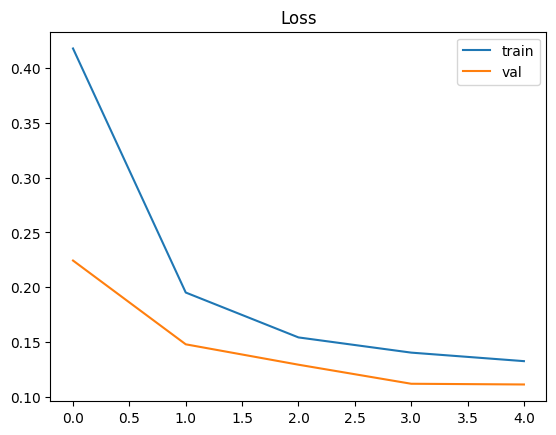

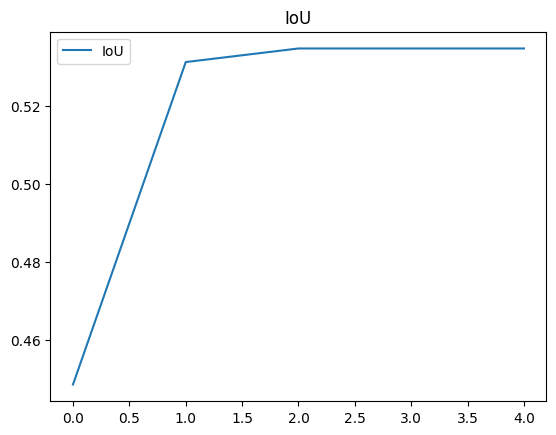

In [115]:
plt.plot(train_losses,label="train")
plt.plot(val_losses,label="val")
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(val_ious,label="IoU")
plt.legend()
plt.title("IoU")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.152924].


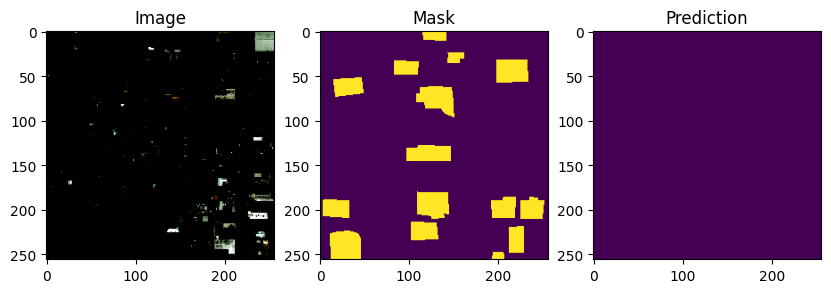

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6384108..1.5810428].


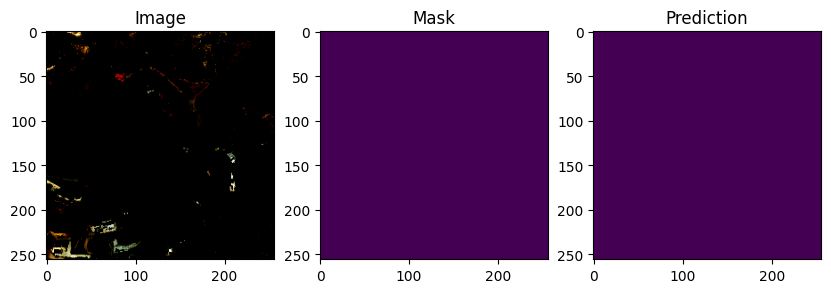

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9980307..2.2489083].


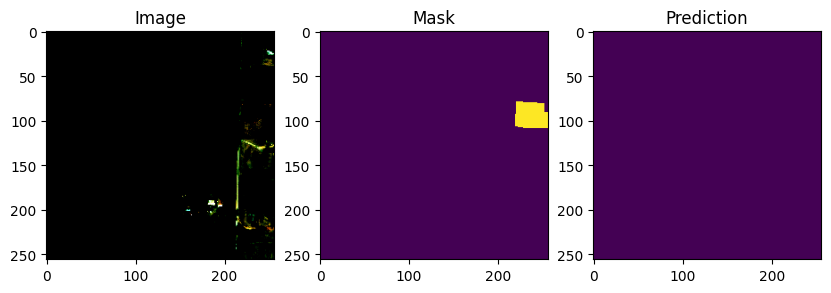

In [116]:
def visualize(model,dataset,n=3):

    model.eval()

    for i in range(n):

        img,mask = dataset[i]

        with torch.no_grad():
            pred = model(img.unsqueeze(0).float().to(device))
            pred = torch.argmax(pred,1).cpu().squeeze()

        plt.figure(figsize=(10,3))

        plt.subplot(1,3,1)
        plt.title("Image")
        plt.imshow(img[:3].permute(1,2,0))

        plt.subplot(1,3,2)
        plt.title("Mask")
        plt.imshow(mask)

        plt.subplot(1,3,3)
        plt.title("Prediction")
        plt.imshow(pred)

        plt.show()

visualize(model, XDataset(val_pairs))